In [1]:
from vrae.vrae import VRAE
from vrae.utils import *
import time
import shutil
import numpy as np
import torch
import torch.nn as nn   
import pandas as pd
import plotly
from torch.utils.data import DataLoader, TensorDataset
plotly.offline.init_notebook_mode()
from tslearn.preprocessing import TimeSeriesScalerMeanVariance 
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sklearn.metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
from tsaug.visualization import plot
from tsaug import TimeWarp, Crop, Quantize, Drift, Reverse, AddNoise

def first_NaN_index(serie):
    return(np.where(np.isnan(serie))[0][0] if np.sum(np.isnan(serie))>0 else len(serie))

def my_scaler(data, feature_range = (0,1)): #list of series
    global_min = np.min([np.min(np.log(serie)) for serie in data])
    global_max = np.max([np.max(np.log(serie)) for serie in data])
    data_scaled = []
    for serie in data:
        serie = np.log(serie)
        serie = (serie - global_min) / (global_max - global_min)
        serie = serie * (feature_range[1] - feature_range[0]) + feature_range[0]
        data_scaled.append(serie)
    return(data_scaled)

def encode_sequence_1dim(vrae_model, sequence):
    vrae_model.eval()
    vrae_model.batch_size = 1
    input_seq = torch.from_numpy(sequence).float().unsqueeze(1).unsqueeze(0).unsqueeze(0).cuda()
    latent = vrae_model.transform(input_seq)
    return latent[0,:]

def encode_sequence_Ndim(vrae_model, sequence):
    vrae_model.eval()
    vrae_model.batch_size = 1
    input_seq = torch.from_numpy(sequence).float().unsqueeze(0).unsqueeze(0).cuda()
    latent = vrae_model.transform(input_seq)
    return latent[0,:]

def forward_sequence_1dim(vrae_model, sequence):
    if sequence.shape[0]>vrae_model.sequence_length:
        print(f'Sequence not {vrae_model.sequence_length}')
        return(-1)
    vrae_model.eval()
    fake_batch_200 = np.tile(sequence, (200, 1)).T
    fake_batch_200 = torch.from_numpy(fake_batch_200).float().unsqueeze(2).cuda()
    reconstruction = vrae_model.forward(fake_batch_200)
    return reconstruction[0][:,0,:].cpu().detach().numpy()

In [2]:
liste_x = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\seq_all_x.npy',allow_pickle=True)
liste_y = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\seq_all_y.npy',allow_pickle=True)

# Scale the sequences, dattaset-wise
liste_x_scaled_size = my_scaler([x[0] for x in liste_x], feature_range=(-1,1))
liste_x_scaled_SOS = my_scaler([x[1] for x in liste_x], feature_range=(-1,1))
liste_x_scaled_mcherry = my_scaler([x[2] for x in liste_x], feature_range=(-1,1))
#combine the 3 scaled signals into one multivariate time series
combined_scaled = []
for size_s,sos_s, mcherry_s in zip(liste_x_scaled_size, liste_x_scaled_SOS, liste_x_scaled_mcherry):
    combined_scaled.append(np.vstack((size_s, sos_s, mcherry_s),).T)
#select one experiments from each condition as training set
training_experiments = ['gly_control_1','glu_control_1','gluaa_control_1','gly_cip_1','glu_cip_1','gluaa_cip_1','gly_ciptet_1','glu_ciptet_1','gluaa_ciptet_1']
liste_x_train = []
liste_y_train = []
for i in range(len(liste_y)):
    medium,treatment,replicate,t_death,DeathSubtype = liste_y[i]
    exp_name = f'{medium}_{treatment}_{replicate}'
    if exp_name in training_experiments:
        liste_x_train.append(combined_scaled[i])
        liste_y_train.append(liste_y[i])

# arr_x_train = np.array(liste_x_train)[:,:,np.newaxis]
# arr_y_train = np.array(liste_y_train)

# train tes stplit before augmentation to prevent data leakage
X_train_preaug, X_test_preaug, y_train_preaug, y_test_preaug = train_test_split(liste_x_train, liste_y_train, test_size=0.1, random_state=42, shuffle=True)


# my_augmenter = (TimeWarp() * 16  # random time warping 5 times in parallel
#                 + Drift(max_drift=(0.05, 0.1)) @ 0.8  # with 80% probability, random drift the signal up to 5% - 10%
#                 + AddNoise(scale=0.01)
#                 )
# X_train_preaug = my_augmenter.augment(X_train_preaug)

liste_x_train_aug = []
liste_y_train_aug = []
for i in range(len(X_train_preaug)):
    for j in range(0,len(X_train_preaug[i])-72+1,6):
        liste_x_train_aug.append(X_train_preaug[i][j:j+72,:])
        liste_y_train_aug.append(y_train_preaug[i])

X_train = np.array(liste_x_train_aug)
y_train = np.array(liste_y_train_aug)

liste_x_test_aug = []
liste_y_test_aug = []
for i in range(len(X_test_preaug)):
    for j in range(0,len(X_test_preaug[i])-72+1,72):
        liste_x_test_aug.append(X_test_preaug[i][j:j+72,:])
        liste_y_test_aug.append(y_test_preaug[i])

X_test = np.array(liste_x_test_aug)
y_test = np.array(liste_y_test_aug)

# # # save those 4 arrays
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\X_train_multivar_analysis_72.npy', X_train)
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\X_test_multivar_analysis_72.npy', X_test)
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\y_train_multivar_analysis_72.npy', y_train)
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\y_test_multivar_analysis_72.npy', y_test)

In [3]:
from vrae.vrae import VRAE
import time
import shutil
import numpy as np
import torch
import torch.nn as nn   
from torch.utils.data import DataLoader, TensorDataset

X_train = np.load(fr'numpy_save_files/X_train_multivar_analysis_72.npy', allow_pickle=True)
X_test = np.load(fr'numpy_save_files/X_test_multivar_analysis_72.npy', allow_pickle=True)
y_train = np.load(fr'numpy_save_files/y_train_multivar_analysis_72.npy', allow_pickle=True)
y_test = np.load(fr'numpy_save_files/y_test_multivar_analysis_72.npy', allow_pickle=True)

print('X_train shape\t',X_train.shape,'\t X_test shape\t',X_test.shape)

train_size = TensorDataset(torch.from_numpy(X_train[:,:,0,np.newaxis]).to('cuda'))
test_size = TensorDataset(torch.from_numpy(X_test[:,:,0,np.newaxis]).to('cuda'))

train_sos = TensorDataset(torch.from_numpy(X_train[:,:,1,np.newaxis]).to('cuda'))
test_sos = TensorDataset(torch.from_numpy(X_test[:,:,1,np.newaxis]).to('cuda'))

train_mcherry = TensorDataset(torch.from_numpy(X_train[:,:,2,np.newaxis]).to('cuda'))
test_mcherry = TensorDataset(torch.from_numpy(X_test[:,:,2,np.newaxis]).to('cuda'))

train_size_sos = TensorDataset(torch.from_numpy(X_train[:,:,:2]).to('cuda'))
test_size_sos = TensorDataset(torch.from_numpy(X_test[:,:,:2]).to('cuda'))

train_size_mcherry = TensorDataset(torch.from_numpy(X_train[:,:,::2]).to('cuda'))
test_size_mcherry = TensorDataset(torch.from_numpy(X_test[:,:,::2]).to('cuda'))

train_sos_mcherry = TensorDataset(torch.from_numpy(X_train[:, :,1:]).to('cuda'))
test_sos_mcherry = TensorDataset(torch.from_numpy(X_test[:, :,1:]).to('cuda'))

train_size_sos_mcherry = TensorDataset(torch.from_numpy(X_train).to('cuda'))
test_size_sos_mcherry = TensorDataset(torch.from_numpy(X_test).to('cuda'))

# train_dataset = train_size
# test_dataset = test_size
# folder = 'multivar_72_size'
# number_of_features = 1

# for replicate in [0]:
#     t0 = time.time()

#     sequence_length = 72

#     dload = './model_dir_mm' #download directory
#     hidden_size = 90
#     hidden_layer_depth = 2
#     batch_size = 100
#     learning_rate = 0.0005 # 0.0005
#     n_epochs = 200
#     dropout_rate = 0.2
#     optimizer = 'Adam' # options: ADAM, SGD
#     cuda = True # options: True, False
#     print_every=1000
#     clip = True # options: True, False
#     max_grad_norm=5
#     loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
#     block = 'LSTM' # options: LSTM, GRU


#     for latent_length in range(30,5-1,-1):
#         print('latent_length\t',latent_length,'\t ', 'number_of_features\t',number_of_features,'\t', 'hidden_size\t',hidden_size, '\t', 'hidden_layer_depth\t',hidden_layer_depth,'\t', 'batch_size\t',batch_size,'\t','learning_rate\t',learning_rate,'\t','n_epochs\t',n_epochs)
#         print('elapsed time\t',(time.time()-t0)/60,' minutes\t',(time.time()-t0)/3600.0,' hours')

#         vrae = VRAE(sequence_length=sequence_length,
#                     number_of_features = number_of_features,
#                     hidden_size = hidden_size, 
#                     hidden_layer_depth = hidden_layer_depth,
#                     latent_length = latent_length,
#                     batch_size = batch_size,
#                     learning_rate = learning_rate,
#                     n_epochs = n_epochs,
#                     dropout_rate = dropout_rate,
#                     optimizer = optimizer, 
#                     cuda = cuda,
#                     print_every=print_every, 
#                     clip=clip, 
#                     max_grad_norm=max_grad_norm,
#                     loss = loss,
#                     block = block,
#                     dload = dload)

#         vrae.fit(train_dataset, test_dataset, save=True)

#         file = open(fr'model_dir_mm/print.txt').readlines()
#         train_losses = []
#         test_losses = []
#         for line in file:
#             if 'Average loss' in line:
#                 train_losses.append(float(line.split(' ')[-2]))
#                 test_losses.append(float(line.split(' ')[-1][:-2]))

#         # shutil.move(fr'model_dir_mm/model.pth', fr'{folder}/model_{replicate}_{latent_length}.pth')
#         # shutil.move(fr'model_dir_mm/model_best.pth', fr'{folder}/model_best_{replicate}_{latent_length}.pth')
#         # np.save(fr'{folder}/train_losses_{replicate}_{latent_length}.npy', train_losses)
#         # np.save(fr'{folder}/test_losses_{replicate}_{latent_length}.npy', test_losses)
#         # print('elapsed time\t',(time.time()-t0)/60,' minutes\t',(time.time()-t0)/3600.0,' hours')

X_train shape	 (71618, 72, 3) 	 X_test shape	 (814, 72, 3)


Processing condition: size
Processing condition: sos
Processing condition: mcherry
Processing condition: size_sos
Processing condition: size_mcherry
Processing condition: sos_mcherry
Processing condition: size_sos_mcherry


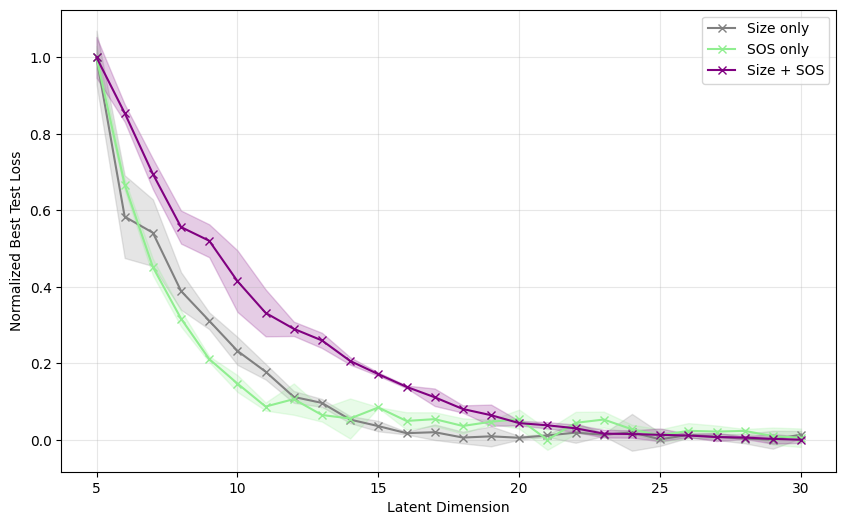

In [4]:
latent_test_dict={}
for condition in ['size', 'sos', 'mcherry', 'size_sos', 'size_mcherry', 'sos_mcherry', 'size_sos_mcherry']:
    print(f'Processing condition: {condition}')
    ## trainig curves
    plot_until_epoch = 200
    n_replicate = 4
    latent_range = range(5,30+1)
    path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_{condition}'
    loss_dict = {}
    for latent_length in latent_range:
        loss_dict[latent_length] = ([],[])
        for replicate in [0,1,3,4]:#range(n_replicate):
            train_losses = np.load(fr'{path}\train_losses_{replicate}_{latent_length}.npy')
            test_losses = np.load(fr'{path}\test_losses_{replicate}_{latent_length}.npy')
            loss_dict[latent_length][0].append(train_losses)
            loss_dict[latent_length][1].append(test_losses)

    # plot mean train loss and mean test loss with std curves+fill as a function of latent dimension using loss_dict 
    mean_train_losses = np.zeros((len(latent_range),plot_until_epoch))
    mean_test_losses = np.zeros((len(latent_range),plot_until_epoch))
    std_train_losses = np.zeros((len(latent_range),plot_until_epoch))
    std_test_losses = np.zeros((len(latent_range),plot_until_epoch))

    # latent_range = [0]#range(7)
    # #replace keys in loss_dict accordingly
    # for i,k in enumerate(range(50,51,5)):
    #     loss_dict[i] = loss_dict[k]

    for latent_length in latent_range:
        mean_train_losses[latent_length-latent_range[0]] = np.mean([arr[:plot_until_epoch] for arr in loss_dict[latent_length][0]], axis=0)
        mean_test_losses[latent_length-latent_range[0]] = np.mean([arr[:plot_until_epoch] for arr in loss_dict[latent_length][1]], axis=0)
        std_train_losses[latent_length-latent_range[0]] = np.std([arr[:plot_until_epoch] for arr in loss_dict[latent_length][0]], axis=0)
        std_test_losses[latent_length-latent_range[0]] = np.std([arr[:plot_until_epoch] for arr in loss_dict[latent_length][1]], axis=0)

    # fig,ax = plt.subplots(1,2,figsize=(27,8))
    # cmap = plt.get_cmap('jet')
    # colors = [cmap(x) for x in np.linspace(0, 0.9, len(latent_range))]
    # for latent_length in latent_range:
    #     ax[0].plot(mean_train_losses[latent_length-latent_range[0],:plot_until_epoch], label=f'train latent {latent_length}', color=colors[latent_range[0]-latent_length])
    #     ax[0].fill_between(range(plot_until_epoch), 
    #                     mean_train_losses[latent_length-latent_range[0],:plot_until_epoch]-std_train_losses[latent_length-latent_range[0],:plot_until_epoch], 
    #                     mean_train_losses[latent_length-latent_range[0],:plot_until_epoch]+std_train_losses[latent_length-latent_range[0],:plot_until_epoch], 
    #                     color=colors[latent_range[0]-latent_length], alpha=0.3)
    #     ax[1].plot(mean_test_losses[latent_length-latent_range[0],:plot_until_epoch], label=f'test latent {latent_length}', color=colors[latent_range[0]-latent_length])
    #     ax[1].fill_between(range(plot_until_epoch), 
    #                     mean_test_losses[latent_length-latent_range[0],:plot_until_epoch]-std_test_losses[latent_length-latent_range[0],:plot_until_epoch], 
    #                     mean_test_losses[latent_length-latent_range[0],:plot_until_epoch]+std_test_losses[latent_length-latent_range[0],:plot_until_epoch], 
    #                     color=colors[latent_range[0]-latent_length], alpha=0.3)
    #     ax[0].set_title('Train Losses with Std Dev')
    #     ax[1].set_title('Test Losses with Std Dev')
    #     ax[0].set_xlabel('Epochs')
    #     ax[1].set_xlabel('Epochs')
    #     ax[0].set_ylabel('Loss')
    # plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

    # plot best test loss with std curves+fill as a function of latent dimension
    std_test_losses = []
    best_test_loss = []
    for latent_length in latent_range:
        test_losses = [arr[:plot_until_epoch] for arr in loss_dict[latent_length][1]]
        best_losses = np.min(np.array(test_losses)[:,-1])
        std_loss = np.std(np.array(test_losses)[:,-1])
        best_test_loss.append(best_losses)
        std_test_losses.append(std_loss)
    # plt.figure(figsize=(10,6))
    # plt.plot(latent_range, best_test_loss, marker='o', label='Best Test Loss', color='blue')
    # plt.xlabel('Latent Dimension')
    # plt.ylabel('Best Test Loss')
    latent_test_dict[condition] = (latent_range, best_test_loss, std_test_losses)

plt.figure(figsize=(10,6))

colors = {'size':'grey', 'sos':'lightgreen', 'size_sos':'purple'}
names = {'size':'Size only', 'sos':'SOS only', 'size_sos':'Size + SOS'}
for condition in ['size', 'sos', 'size_sos']:#latent_test_dict.keys():
    latent_range, best_test_loss, std_test_losses = latent_test_dict[condition]
    
    # Normalize to 0-1 range
    best_test_loss_arr = np.array(best_test_loss)
    std_test_losses_arr = np.array(std_test_losses)
    
    min_loss = np.min(best_test_loss_arr)
    max_loss = np.max(best_test_loss_arr)
    
    normalized_loss = (best_test_loss_arr - min_loss) / (max_loss - min_loss)
    normalized_std = std_test_losses_arr / (max_loss - min_loss)
    
    plt.plot(latent_range, normalized_loss, marker='x', label=names[condition], color=colors[condition])
    plt.fill_between(latent_range, 
                     normalized_loss - normalized_std, 
                     normalized_loss + normalized_std, 
                     alpha=0.2, color=colors[condition])

plt.legend()
plt.xlabel('Latent Dimension')
plt.ylabel('Normalized Best Test Loss')
# plt.title('Normalized Test Loss vs Latent Dimension by Condition')
plt.grid(True, alpha=0.3)
plt.show()

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.



torch.Size([72, 100, 1])
22
(72, 1)
torch.Size([72, 100, 1])
86
(72, 1)
torch.Size([72, 100, 1])
50
(72, 1)
torch.Size([72, 100, 2])
28
(72, 2)
torch.Size([72, 100, 2])
47
(72, 2)
torch.Size([72, 100, 2])
52
(72, 2)
torch.Size([72, 100, 3])
17
(72, 3)


Text(0.5, 0, 'Timepoints')

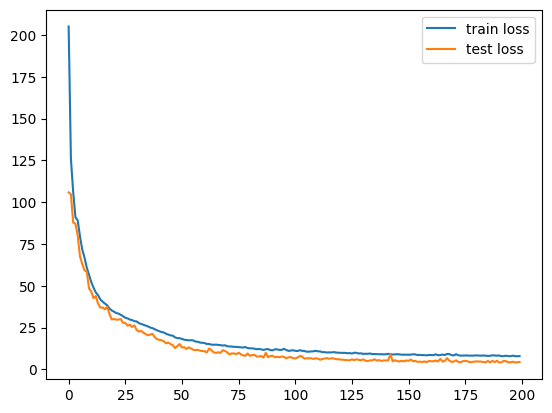

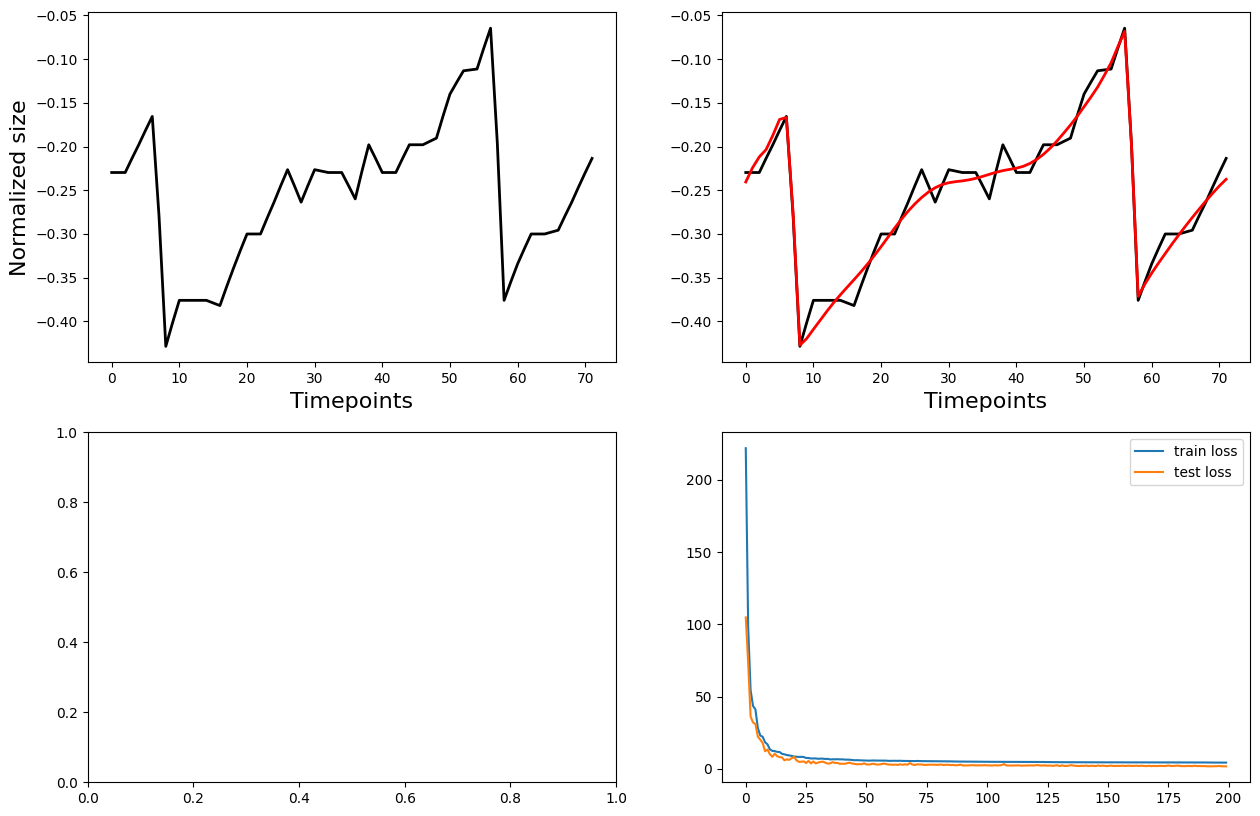

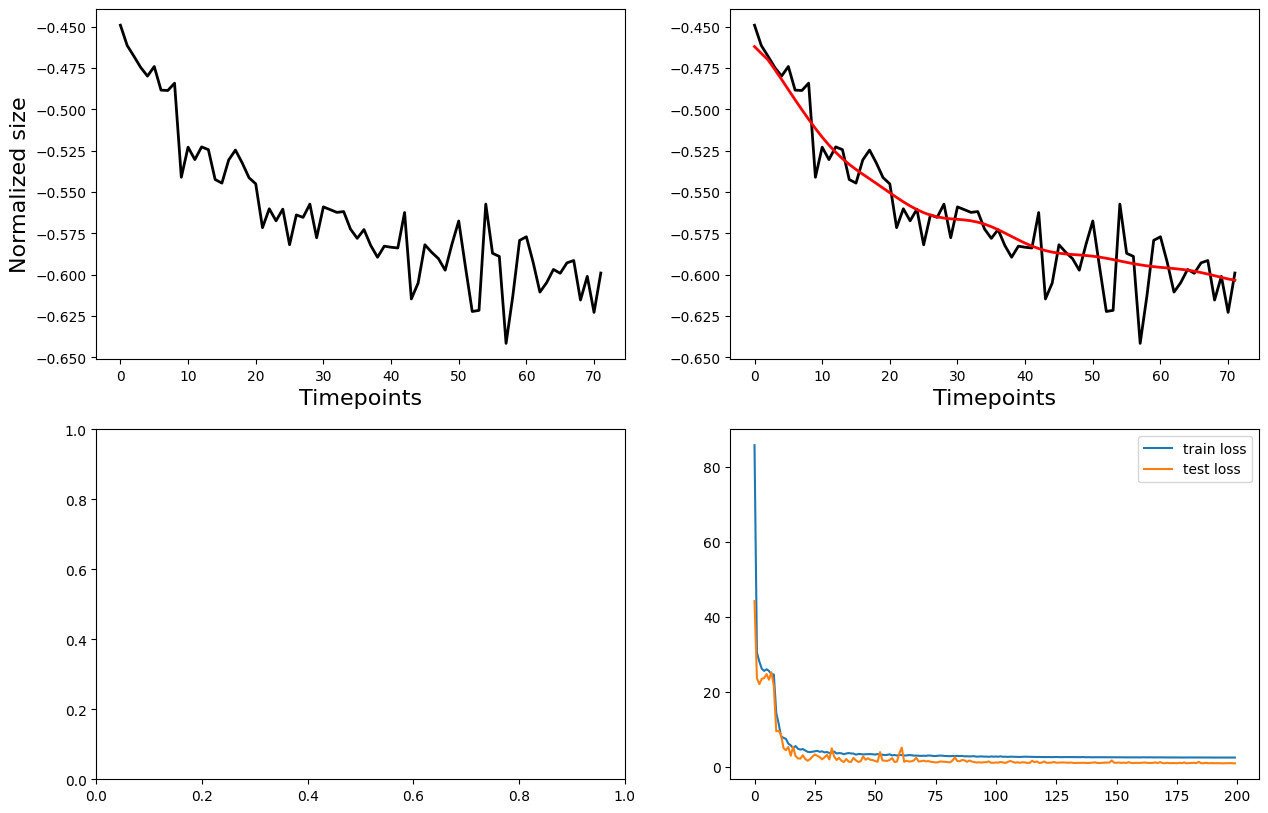

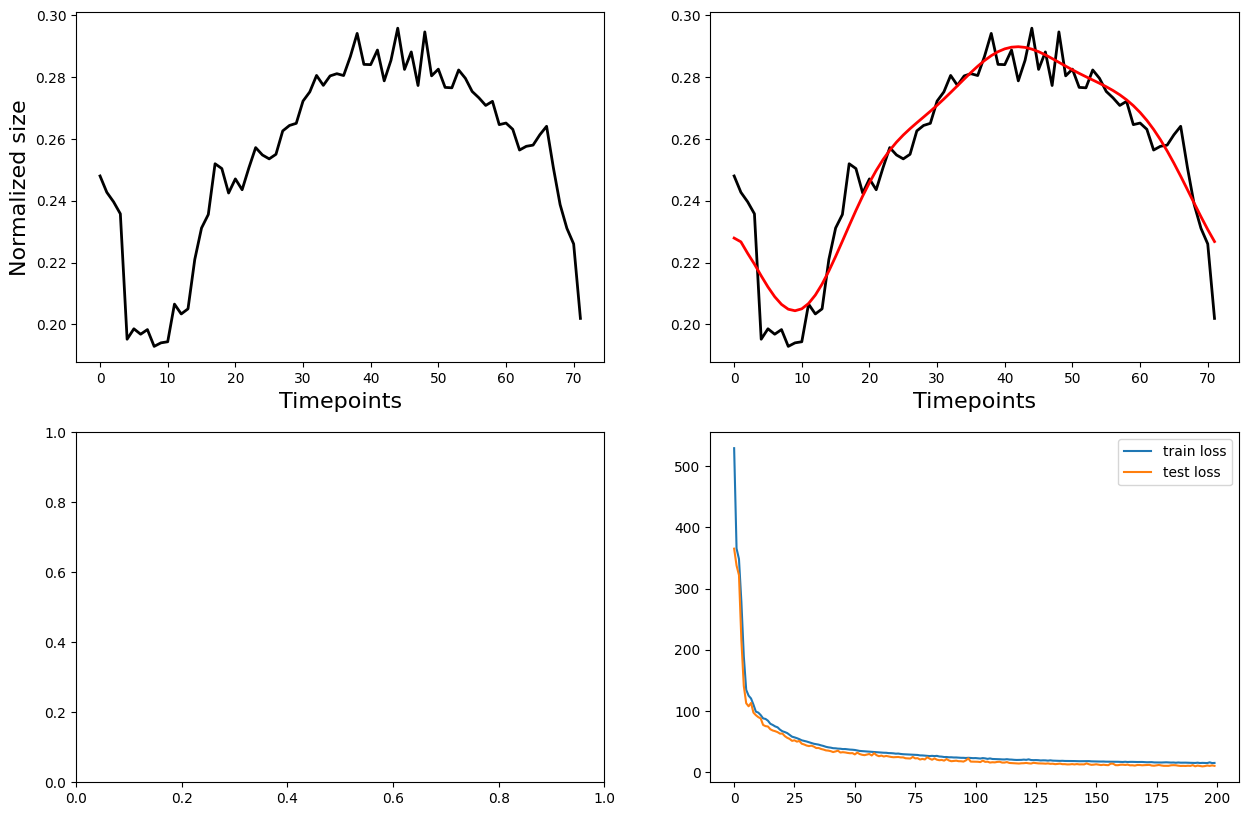

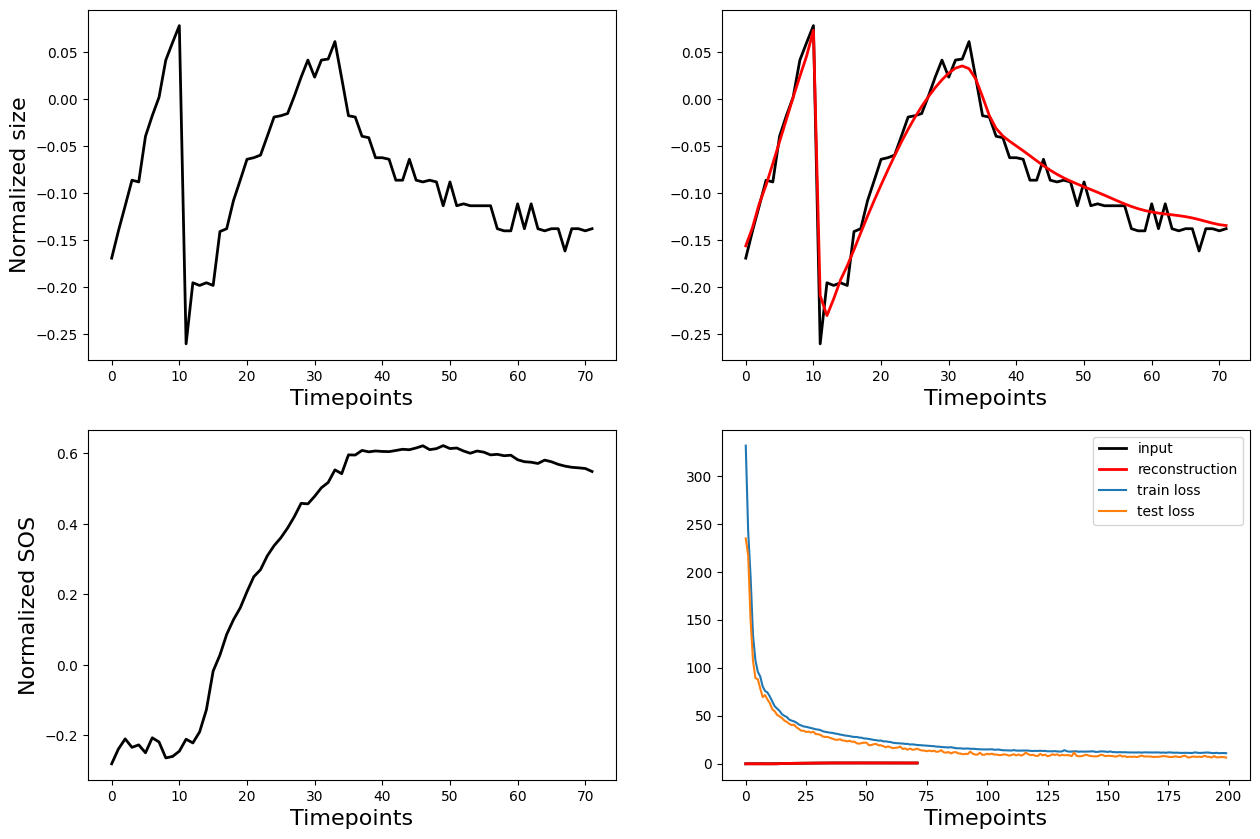

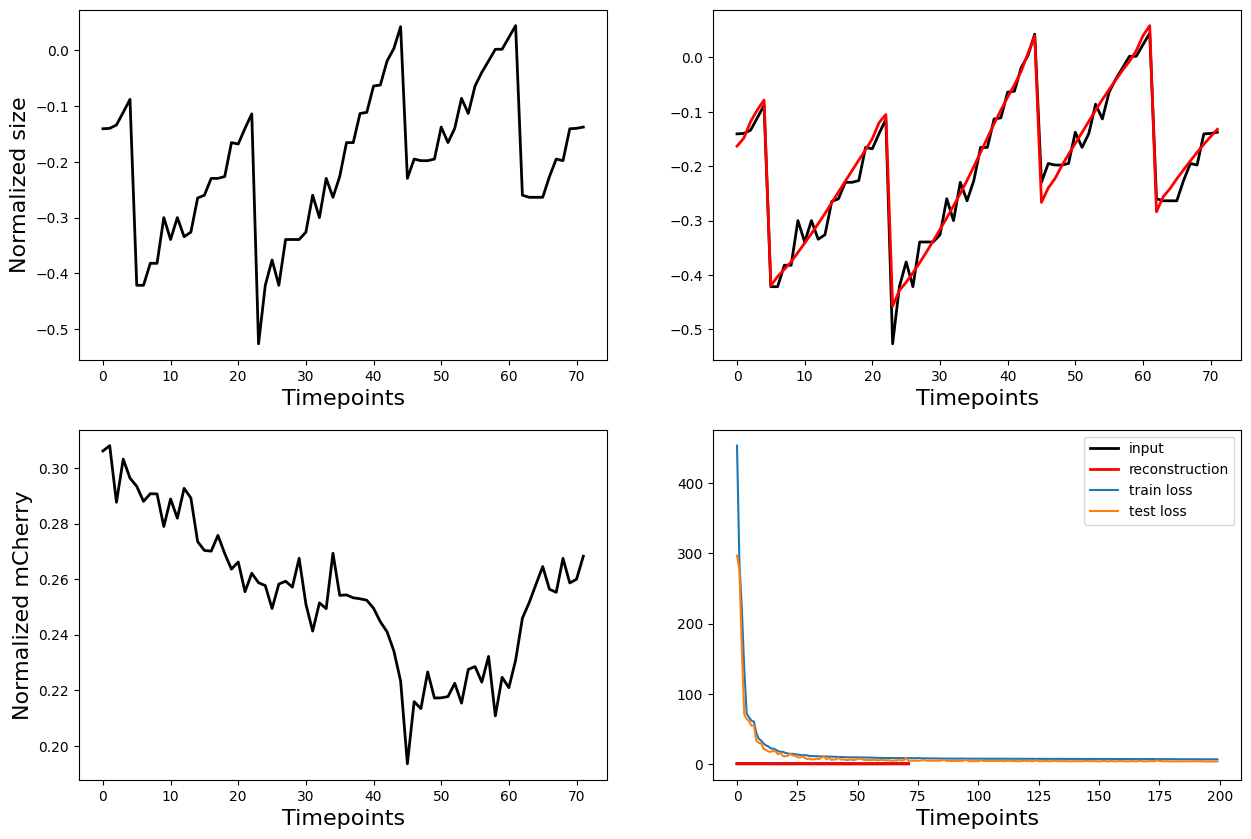

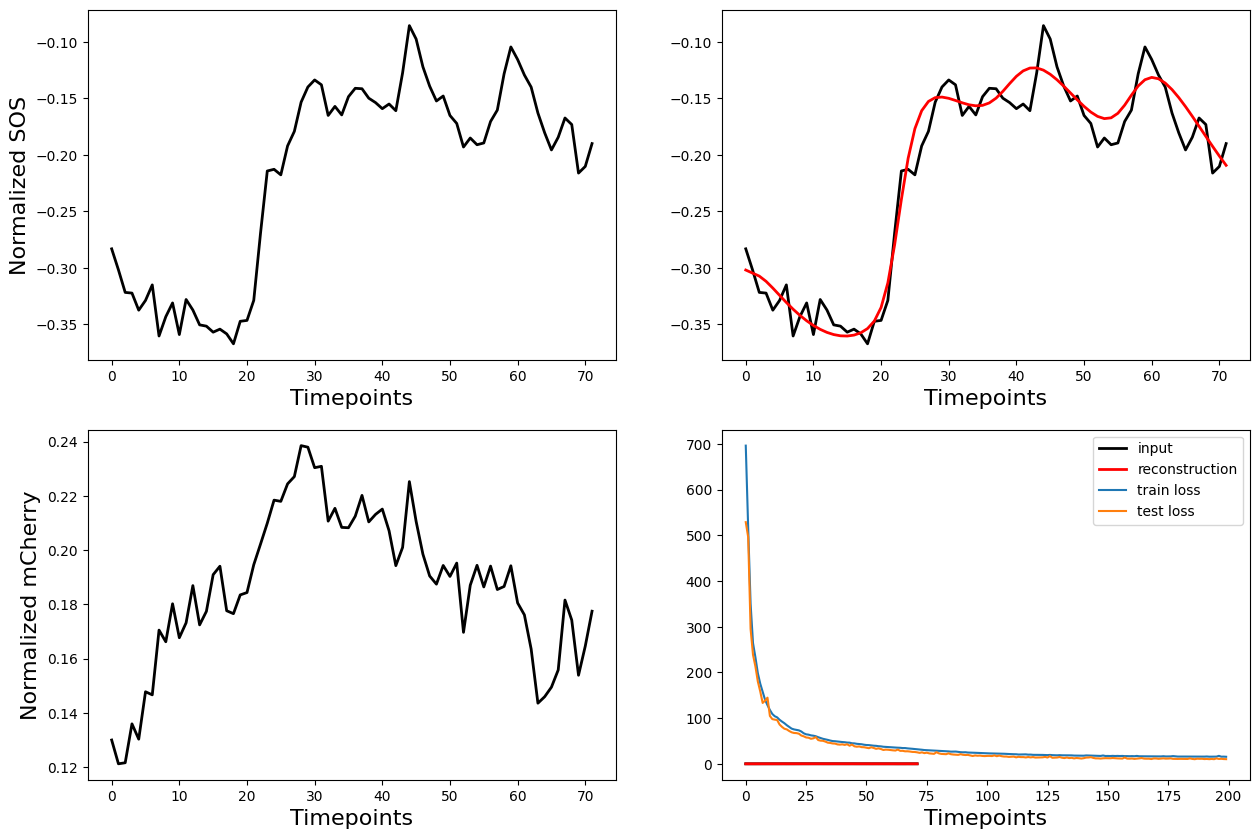

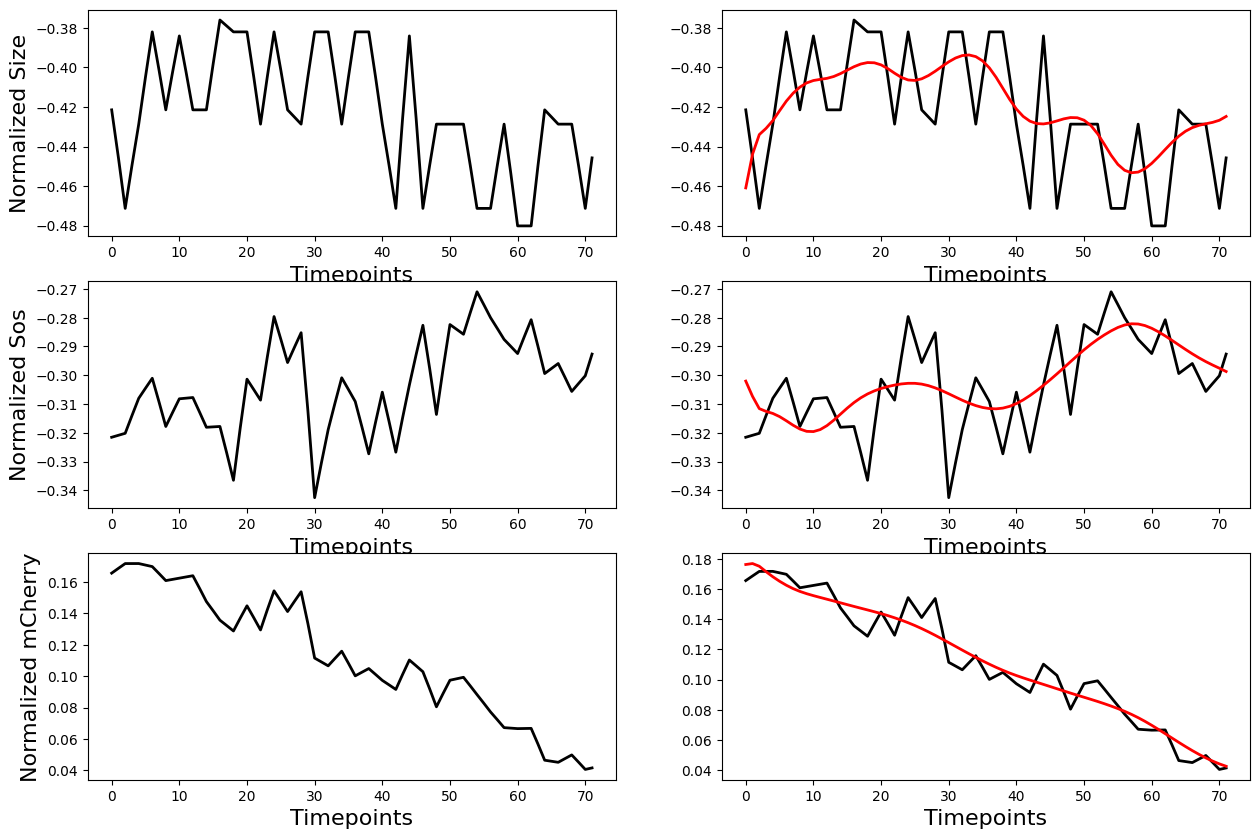

In [5]:
## Importing size model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size'
latent_length=15
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 1
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_size = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_size.load(fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_size.eval()
testseq2 = test_size[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_size.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)


## Importing sos model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_sos'
latent_length=11
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 1
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_sos = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_sos.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_sos.eval()
testseq2 = test_sos[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_sos.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)


## Importing mcherry model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_mcherry'
latent_length=12
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 1
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_mcherry = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_mcherry.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_mcherry.eval()
testseq2 = test_mcherry[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_mcherry.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)


## Importing size_sos model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size_sos'
latent_length=20
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 2
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_size_sos = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_size_sos.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_size_sos.eval()
testseq2 = test_size_sos[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_size_sos.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)

ax[1,0].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(output_seq[:,1], color='red',linewidth = 2, label='reconstruction')
ax[1,0].set_xlabel('Timepoints', fontsize=16)
ax[1,0].set_ylabel('Normalized SOS', fontsize=16)
ax[1,1].set_xlabel('Timepoints', fontsize=16)

## Importing size_mcherry model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size_mcherry'
latent_length=18
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 2
latent_length = 25
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_size_mcherry = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_size_mcherry.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_size_mcherry.eval()
testseq2 = test_size_mcherry[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_size_mcherry.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)

ax[1,0].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(output_seq[:,1], color='red',linewidth = 2, label='reconstruction')
ax[1,0].set_xlabel('Timepoints', fontsize=16)
ax[1,0].set_ylabel('Normalized mCherry', fontsize=16)
ax[1,1].set_xlabel('Timepoints', fontsize=16)

## Importing sos_mcherry model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_sos_mcherry'
latent_length=15
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 2
latent_length = 25
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_sos_mcherry = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_sos_mcherry.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_sos_mcherry.eval()
testseq2 = test_sos_mcherry[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_sos_mcherry.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized SOS', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)

ax[1,0].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(output_seq[:,1], color='red',linewidth = 2, label='reconstruction')
ax[1,0].set_xlabel('Timepoints', fontsize=16)
ax[1,0].set_ylabel('Normalized mCherry', fontsize=16)
ax[1,1].set_xlabel('Timepoints', fontsize=16)

## Importing size_sos_mcherry model
path=fr'C:\Users\achfr\timeseries-clustering-vae\multivar_72_size_sos_mcherry'
latent_length=25
train_losses = np.load(fr'{path}\train_losses_0_{latent_length}.npy')
test_losses = np.load(fr'{path}\test_losses_0_{latent_length}.npy')
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()

## load model 
sequence_length = 72
number_of_features = 3
latent_length = 25
best_replicate = 0

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 400
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained_size_sos_mcherry = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_size_sos_mcherry.load(path+fr'\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained_size_sos_mcherry.eval()
testseq2 = test_size_sos_mcherry[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained_size_sos_mcherry.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(3,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized Size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)

ax[1,0].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(output_seq[:,1], color='red',linewidth = 2, label='reconstruction')
ax[1,0].set_xlabel('Timepoints', fontsize=16)
ax[1,0].set_ylabel('Normalized Sos', fontsize=16)
ax[1,1].set_xlabel('Timepoints', fontsize=16)

ax[2,0].plot(input_seq[:,2], color ='black',linewidth = 2, label='input')
ax[2,1].plot(input_seq[:,2], color ='black',linewidth = 2, label='input')
ax[2,1].plot(output_seq[:,2], color='red',linewidth = 2, label='reconstruction')
ax[2,0].set_xlabel('Timepoints', fontsize=16)   
ax[2,0].set_ylabel('Normalized mCherry', fontsize=16)
ax[2,1].set_xlabel('Timepoints', fontsize=16)

In [ ]:
#create dataset with all non training experiments, 3m30s
training_experiments = ['gly_control_1','glu_control_1','gluaa_control_1','gly_cip_1','glu_cip_1','gluaa_cip_1','gly_ciptet_1','glu_ciptet_1','gluaa_ciptet_1']
liste_x_downstream = []
liste_y_downstream = []
for i in range(len(liste_y)):
    medium,treatment,replicate,t_death,DeathSubtype = liste_y[i]
    exp_name = f'{medium}_{treatment}_{replicate}'
    if exp_name not in training_experiments:
        liste_x_downstream.append(combined_scaled[i])
        liste_y_downstream.append(liste_y[i])

downstream_datasets = np.load('numpy_save_files/downstream_datasets_multivar_72.npy', allow_pickle=True).item()

# downstream_datasets={}
# ### create size dataset for downstream analysis

# #size only, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_1dim(vrae_trained_size, liste_x_downstream[i][24:96,0]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_8']= (np.array(x_list), np.array(y_list))

# #size only, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_1dim(vrae_trained_size, liste_x_downstream[i][24:96,0]), encode_sequence_1dim(vrae_trained_size, liste_x_downstream[i][96:96+72,0])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_16']= (np.array(x_list), np.array(y_list))

# #size only, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_1dim(vrae_trained_size, liste_x_downstream[i][:,0]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_full']= (np.array(x_list), np.array(y_list))

# #sos only, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_1dim(vrae_trained_sos, liste_x_downstream[i][24:96,1]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['sos_8']= (np.array(x_list), np.array(y_list))

# #sos only, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_1dim(vrae_trained_sos, liste_x_downstream[i][24:96,1]), encode_sequence_1dim(vrae_trained_sos, liste_x_downstream[i][96:96+72,1])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['sos_16']= (np.array(x_list), np.array(y_list))

# #sos only, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_1dim(vrae_trained_sos, liste_x_downstream[i][:,1]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['sos_full']= (np.array(x_list), np.array(y_list))

# # mcherry only, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_1dim(vrae_trained_mcherry, liste_x_downstream[i][24:96,2]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['mcherry_8']= (np.array(x_list), np.array(y_list))

# # mcherry only, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_1dim(vrae_trained_mcherry, liste_x_downstream[i][24:96,2]), encode_sequence_1dim(vrae_trained_mcherry, liste_x_downstream[i][96:96+72,2])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['mcherry_16']= (np.array(x_list), np.array(y_list))

# # mcherry only, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_1dim(vrae_trained_mcherry, liste_x_downstream[i][:,2]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['mcherry_full']= (np.array(x_list), np.array(y_list))

# #size_sos, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_size_sos, liste_x_downstream[i][24:96,:2]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_sos_8']= (np.array(x_list), np.array(y_list))

# #size_sos, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_Ndim(vrae_trained_size_sos, liste_x_downstream[i][24:96,:2]), encode_sequence_Ndim(vrae_trained_size_sos, liste_x_downstream[i][96:96+72,:2])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_sos_16']= (np.array(x_list), np.array(y_list))

# #size_sos, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_size_sos, liste_x_downstream[i][:,:2]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_sos_full']= (np.array(x_list), np.array(y_list))

# #size_mcherry, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_size_mcherry, liste_x_downstream[i][24:96,[0,2]]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_mcherry_8']= (np.array(x_list), np.array(y_list))

# #size_mcherry, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_Ndim(vrae_trained_size_mcherry, liste_x_downstream[i][24:96,[0,2]]), encode_sequence_Ndim(vrae_trained_size_mcherry, liste_x_downstream[i][96:96+72,[0,2]])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_mcherry_16']= (np.array(x_list), np.array(y_list))

# #size_mcherry, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_size_mcherry, liste_x_downstream[i][:,[0,2]]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_mcherry_full']= (np.array(x_list), np.array(y_list))

# #sos_mcherry, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_sos_mcherry, liste_x_downstream[i][24:96,1:]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['sos_mcherry_8']= (np.array(x_list), np.array(y_list))

# #sos_mcherry, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_Ndim(vrae_trained_sos_mcherry, liste_x_downstream[i][24:96,1:]), encode_sequence_Ndim(vrae_trained_sos_mcherry, liste_x_downstream[i][96:96+72,1:])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['sos_mcherry_16']= (np.array(x_list), np.array(y_list))

# #sos_mcherry, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_sos_mcherry, liste_x_downstream[i][:,1:]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['sos_mcherry_full']= (np.array(x_list), np.array(y_list))

# #size_sos_mcherry, first 6 hours of antibio
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_size_sos_mcherry, liste_x_downstream[i][24:96,:]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_sos_mcherry_8']= (np.array(x_list), np.array(y_list))

# #size_sos_mcherry, 12 antibio hours in two windows
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(np.concatenate([encode_sequence_Ndim(vrae_trained_size_sos_mcherry, liste_x_downstream[i][24:96,:]), encode_sequence_Ndim(vrae_trained_size_sos_mcherry, liste_x_downstream[i][96:96+72,:])]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_sos_mcherry_16']= (np.array(x_list), np.array(y_list))

# #size_sos_mcherry, full length
# x_list = []
# y_list = []
# for i in range(len(liste_y_downstream)):
#     x_list.append(encode_sequence_Ndim(vrae_trained_size_sos_mcherry, liste_x_downstream[i][:,:]))
#     y_list.append(liste_y_downstream[i])
# downstream_datasets['size_sos_mcherry_full']= (np.array(x_list), np.array(y_list))

# np.save('numpy_save_files/downstream_datasets_multivar_72.npy', downstream_datasets, allow_pickle=True)

In [ ]:
from lazypredict.Supervised import LazyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

import seaborn as sns
classifiers = [MLPClassifier(hidden_layer_sizes = np.array([50,20,10]), max_iter=2000, random_state=42),
               GaussianNB(),
               RandomForestClassifier(random_state = 42, class_weight="balanced", criterion = 'gini', max_depth = None, n_estimators = 50), 
               LogisticRegression(random_state = 42, class_weight="balanced", max_iter=1000),
               KNeighborsClassifier(n_neighbors=3),
               XGBClassifier(n_estimators=50, max_depth=6, learning_rate=1, objective='binary:logistic')
               ]


results_downstream_lazy = {}
results_downstream_MLP = {}
antibio = 'ciptet'

for dataset_name in downstream_datasets.keys():
    x_downstream, y_downstream = downstream_datasets[dataset_name]
    y_downstream_antibio = []
    x_downstream_antibio = []
    for i in range(len(y_downstream)):
        if y_downstream[i][1] == 'control':
            y_downstream_antibio.append(0)
            x_downstream_antibio.append(x_downstream[i])
        if y_downstream[i][1] == antibio:
            y_downstream_antibio.append(1)
            x_downstream_antibio.append(x_downstream[i])
    print(dataset_name, '\t', x_downstream.shape, antibio, y_downstream_antibio.count(1), 'control', y_downstream_antibio.count(0))
    X_train_antibio, X_test_antibio, y_train_antibio, y_test_antibio = train_test_split(np.array(x_downstream_antibio), np.array(y_downstream_antibio), test_size=0.2, random_state=42)
    clf = LazyClassifier(verbose=None, ignore_warnings=True, custom_metric=None)
    models, predictions = clf.fit(X_train_antibio, X_test_antibio, y_train_antibio, y_test_antibio)
    results_downstream_lazy[dataset_name] = models

    results_downstream_MLP[dataset_name] = []
    cv = StratifiedKFold(n_splits=5)
    mean_fpr = np.linspace(0, 1, 100)
    for clf in classifiers:
        tprs = []
        aucs = []
        for i, (train, test) in enumerate(cv.split(X_train_antibio, y_train_antibio)):
            X_train_antibio_cv = X_train_antibio[train]
            X_test_antibio_cv = X_train_antibio[test]
            # Train the classifier
            clf.fit(X_train_antibio_cv, y_train_antibio[train])
            probas_ = clf.predict_proba(X_test_antibio_cv)
            # Compute ROC curve and area under the curve
            fpr, tpr, thresholds = roc_curve(y_train_antibio[test], probas_[:, 1])
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0
            roc_auc = auc(fpr, tpr)
            aucs.append(roc_auc)
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_auc = np.std(aucs)
        results_downstream_MLP[dataset_name].append((mean_auc,std_auc))

# np.save('numpy_save_files/results_downstream_lazy_multivar_72_ciptet.npy', results_downstream_lazy, allow_pickle=True)
# np.save('numpy_save_files/results_downstream_MLP_multivar_72_ciptet.npy', results_downstream_MLP, allow_pickle=True)

In [ ]:
downstream_datasets.keys()

In [ ]:
# results_downstream_lazy = np.load('numpy_save_files/results_downstream_lazy_multivar_72_tet.npy', allow_pickle=True).item()
# results_downstream_MLP = np.load('numpy_save_files/results_downstream_MLP_multivar_72_tet.npy', allow_pickle=True).item()

# results_downstream_lazy = np.load('numpy_save_files/results_downstream_lazy_multivar_72_cip.npy', allow_pickle=True).item()
# results_downstream_MLP = np.load('numpy_save_files/results_downstream_MLP_multivar_72_cip.npy', allow_pickle=True).item()

results_downstream_lazy = np.load('numpy_save_files/results_downstream_lazy_multivar_72_ciptet.npy', allow_pickle=True).item()
results_downstream_MLP = np.load('numpy_save_files/results_downstream_MLP_multivar_72_ciptet.npy', allow_pickle=True).item()

datasetnames=''
modelnames =''
values=''
stds = ''
type='8'

# for dataset_name in results_downstream_lazy.keys():
#     if type in dataset_name:
#         datasetnames+=' '+dataset_name
#         modelnames += ' '+str(results_downstream_lazy[dataset_name]['ROC AUC'].keys()[0])
#         values += ' '+str(results_downstream_lazy[dataset_name]['ROC AUC'][0])
valuelist = []
stdlist = []
for dataset_name in results_downstream_MLP.keys():
    if type in dataset_name:
        bestmodel = np.argmax([r[0] for r in results_downstream_MLP[dataset_name]])
        bestmodel = 0
        names = ['MLP', 'Naive_Bayes', 'Random_Forest', 'Logistic_Regression', 'KNN', 'XGBoost']
        modelnames += ' '+str(names[bestmodel])
        values += str(results_downstream_MLP[dataset_name][bestmodel][0])+' '
        stds += str(results_downstream_MLP[dataset_name][bestmodel][1])+' '
        valuelist.append(results_downstream_MLP[dataset_name][bestmodel][0])
        stdlist.append(results_downstream_MLP[dataset_name][bestmodel][1])

# print(datasetnames)
print(modelnames)
print(values)
print(stds)
# histogram 
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,6))
sns.barplot(x=['size', 'sos', 'mcherry', 'size+sos', 'size+mcherry', 'sos+mcherry', 'size+sos+mcherry'], y=valuelist, yerr=stdlist, width=0.4, edgecolor='black', capsize=10)
plt.xticks(rotation=45)
plt.ylabel('ROC AUC', fontsize=16)
plt.title(f'Classification performance (tet vs control)', fontsize=18)

In [ ]:
print(valuelist[0:2])
print(stdlist[0:2])

In [ ]:
# tet_size_sos = [0.7760702919607029, 0.5663401134634012]
# tet_size_sos_std = [0.018855832347457087, 0.011038614579074088]
# cip_size_sos = [0.8882098255280072, 0.9369367047094319]
# cip_size_sos_std = [0.018617578080072694, 0.007208633004608168]
# ciptet_size_sos = [0.7447369107915822, 0.8770774520672521]
# ciptet_size_sos_std = [0.021770990734945768, 0.01406996586402124]

tet_size_sos = [0.7100094564462059, 0.552780790775333]
tet_size_sos_std =[0.01636409492540039, 0.025234174521396948]


cip_size_sos = [0.7845390948395016, 0.8540857773148867]
cip_size_sos_std = [0.034518191886218116, 0.01865545442578068]


ciptet_size_sos = [0.7845390948395016, 0.8540857773148867]
ciptet_size_sos_std = [0.034518191886218116, 0.01865545442578068]


values =  cip_size_sos + tet_size_sos + ciptet_size_sos
stds = cip_size_sos_std + tet_size_sos_std + ciptet_size_sos_std

plt.rcParams.update({'font.size': 18})

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([0,1,3,4,6,7], values, yerr=stds, width=0.4, edgecolor='black', color=['grey','lightgreen','grey','lightgreen','grey','lightgreen'], capsize=5)
ax.bar(9,1,color='grey', edgecolor='black',label='Size')
ax.bar(10,1,color='lightgreen', edgecolor='black', label='SOS')
ax.set_ylabel('Mean ROC AUC')
ax.set_ylim(0, 1)
ax.set_xlim(-1, 8)
ax.set_xticks([0.5, 3.5, 6.5])
ax.set_xticklabels(['Ctrl Vs Cip', 'Ctrl Vs Tet', 'Ctrl Vs CipTet'])

ax.legend( bbox_to_anchor=(0.49, 1), loc='upper left')


In [ ]:

# pca on size 16 dataset
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# whole data pca

z_run = downstream_datasets['size_s_16'][0]

z_run_pca = PCA(n_components=z_run.shape[1]).fit_transform(z_run)
# z_run_tsne = TSNE(perplexity=50, min_grad_norm=1E-12, n_iter=300, learning_rate='auto', init='random').fit_transform(z_run)

plt.figure(figsize=(7,7))
for i in range(z_run_pca.shape[0]):
    medium,treatment,replicate,t_death,DeathSubtype = downstream_datasets['size_sos_16'][1][i]
    if treatment == 'control':
        plt.scatter(z_run_pca[i,0], z_run_pca[i,1], color='blue', alpha=0.5)
        # ax[1].scatter(z_run_tsne[i,0], z_run_tsne[i,1], color='blue', alpha=0.5)
    if treatment == 'cip':
        plt.scatter(z_run_pca[i,0], z_run_pca[i,1], color='red', alpha=0.5)
        # ax[1].scatter(z_run_tsne[i,0], z_run_tsne[i,1], color='red', alpha=0.5)
plt.xlabel('PCA 1', fontsize=16)
plt.ylabel('PCA 2', fontsize=16)

In [ ]:
plt.figure(figsize=(7,7))
plt.plot([], [], 'o', color='blue', label='control')
plt.plot([], [], 'o', color='red', label='cip')
plt.legend(['control', 'cip'], fontsize=14)

In [ ]:
fig,ax = plt.subplots(1,2, figsize=(20,6))
time = np.linspace(0,20,240)
ctrlindex =3248
print(liste_y[ctrlindex])
ax[0].plot(time,liste_x[ctrlindex][0][:240], color='blue', linewidth=1,label='control')
ax[1].plot(time,np.log(liste_x[ctrlindex][1][:240]), color='blue', linewidth=1)
cipindex = 3740 #3591
print(liste_y[cipindex])
ax[0].plot(time,liste_x[cipindex][0][:240], color='red', linewidth=1,label='cip')
ax[1].plot(time,np.log(liste_x[cipindex][1][:240]), color='red', linewidth=1)
tetindex = 4539 #4351
print(liste_y[tetindex])
ax[0].plot(time,liste_x[tetindex][0][:240], color='green', linewidth=1,label='tet')
ax[1].plot(time,np.log(liste_x[tetindex][1][:240]), color='green', linewidth=1)
ciptetindex = 5060
print(liste_y[ciptetindex])
ax[0].plot(time,liste_x[ciptetindex][0][:240], color='orange', linewidth=1,label='ciptet')
ax[1].plot(time,np.log(liste_x[ciptetindex][1][:240]), color='orange', linewidth=1)

# Shade region between 2 and 14 hours on both subplots
ax[0].axvspan(2, 14, color='grey', alpha=0.2)
ax[1].axvspan(2, 14, color='grey', alpha=0.2)

ax[0].set_xlabel('Time (hours)', fontsize=16)
ax[0].set_ylabel('cell Size [μm]', fontsize=16)
ax[1].set_xlabel('Time (hours)', fontsize=16)
ax[1].set_ylabel('log SOS fluorescence [a.u.]', fontsize=16)
ax[0].set_xticks(np.arange(0, 22, 2))
ax[1].set_xticks(np.arange(0, 22, 2))
ax[0].legend(fontsize=14)


In [ ]:
for k,y in enumerate(liste_y):
    if y[1]=='ciptet' and y[0]=='glu' and liste_x[k][0].shape[0]>=240:
        # print(k)
